In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, losses, Model
from tensorflow.keras.datasets import mnist

print(f"TensorFlow Version: {tf.__version__}")
print("Setup complete! GPU available:" if tf.config.list_physical_devices('GPU') else "Running on CPU.")

TensorFlow Version: 2.20.0
Running on CPU.


In [2]:
# 1. Load raw dataset
(x_train, _), (x_test, _) = mnist.load_data()

# 2. Normalize pixel values to range [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# 3. Reshape for Conv2D layers (batch_size, height, width, channels)
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

print(f"Training shape: {x_train.shape}")
print(f"Testing shape: {x_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training shape: (60000, 28, 28, 1)
Testing shape: (10000, 28, 28, 1)


Noise added successfully!


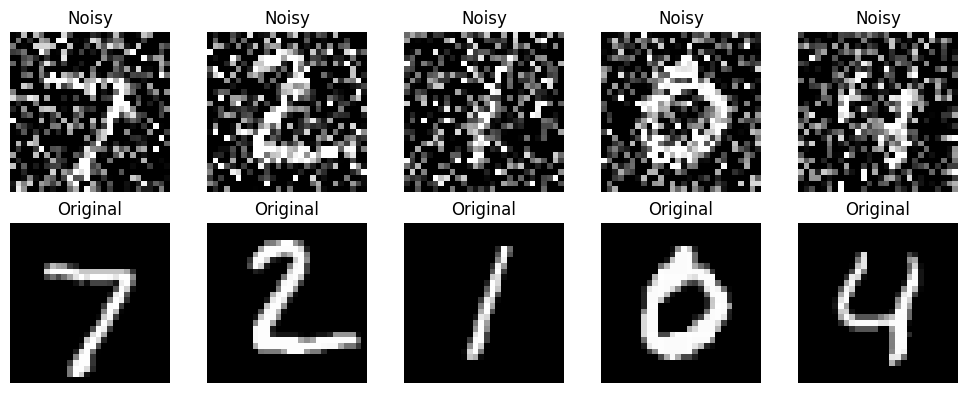

In [3]:
noise_factor = 0.5

# Add random normal noise
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Clip values to ensure valid pixel intensity range [0, 1]
x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_test_noisy = np.clip(x_test_noisy, 0.0, 1.0)

print("Noise added successfully!")

# Quick check: Visualize first 5 noisy vs clean images
plt.figure(figsize=(10, 4))
for i in range(5):
    # Noisy
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")
    # Clean
    ax = plt.subplot(2, 5, i + 6)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [4]:
class DenoisingAutoencoder(Model):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()

        # Encoder: Compresses noisy input to lower dimension
        self.encoder = tf.keras.Sequential([
            layers.Input(shape=(28, 28, 1)),
            layers.Conv2D(32, (3, 3), activation='relu', padding='same', strides=2), # (14, 14, 32)
            layers.Conv2D(16, (3, 3), activation='relu', padding='same', strides=2)  # (7, 7, 16)
        ])

        # Decoder: Reconstructs clean image from latent space
        self.decoder = tf.keras.Sequential([
            layers.Conv2DTranspose(16, kernel_size=3, strides=2, activation='relu', padding='same'), # (14, 14, 16)
            layers.Conv2DTranspose(32, kernel_size=3, strides=2, activation='relu', padding='same'), # (28, 28, 32)
            layers.Conv2D(1, kernel_size=(3, 3), activation='sigmoid', padding='same')               # (28, 28, 1)
        ])

    def call(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

autoencoder = DenoisingAutoencoder()
autoencoder.compile(optimizer='adam', loss=losses.MeanSquaredError())

print("Model architecture created and compiled successfully!")

Model architecture created and compiled successfully!


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 171ms/step - loss: 0.1159 - val_loss: 0.1140
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 169ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 168ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 85s 174ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 76s 161ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 79s 168ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 74s 157ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 155ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 75s 160ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 162ms/step - loss: 0.1120 - val_loss: 0.1140


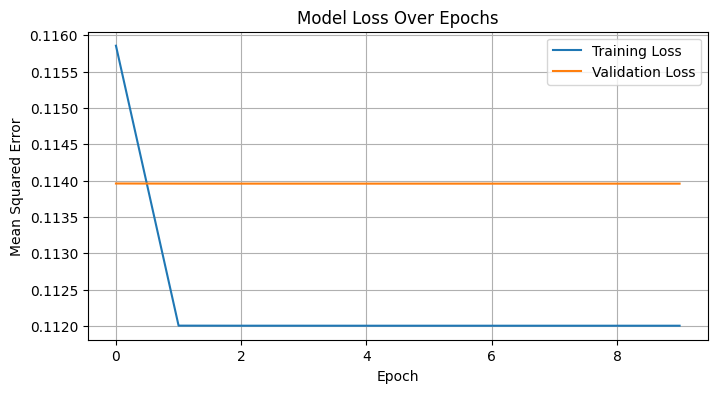

In [5]:
# Train: Input = Noisy images, Target = Clean original images
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

# Plot Training & Validation Loss
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step


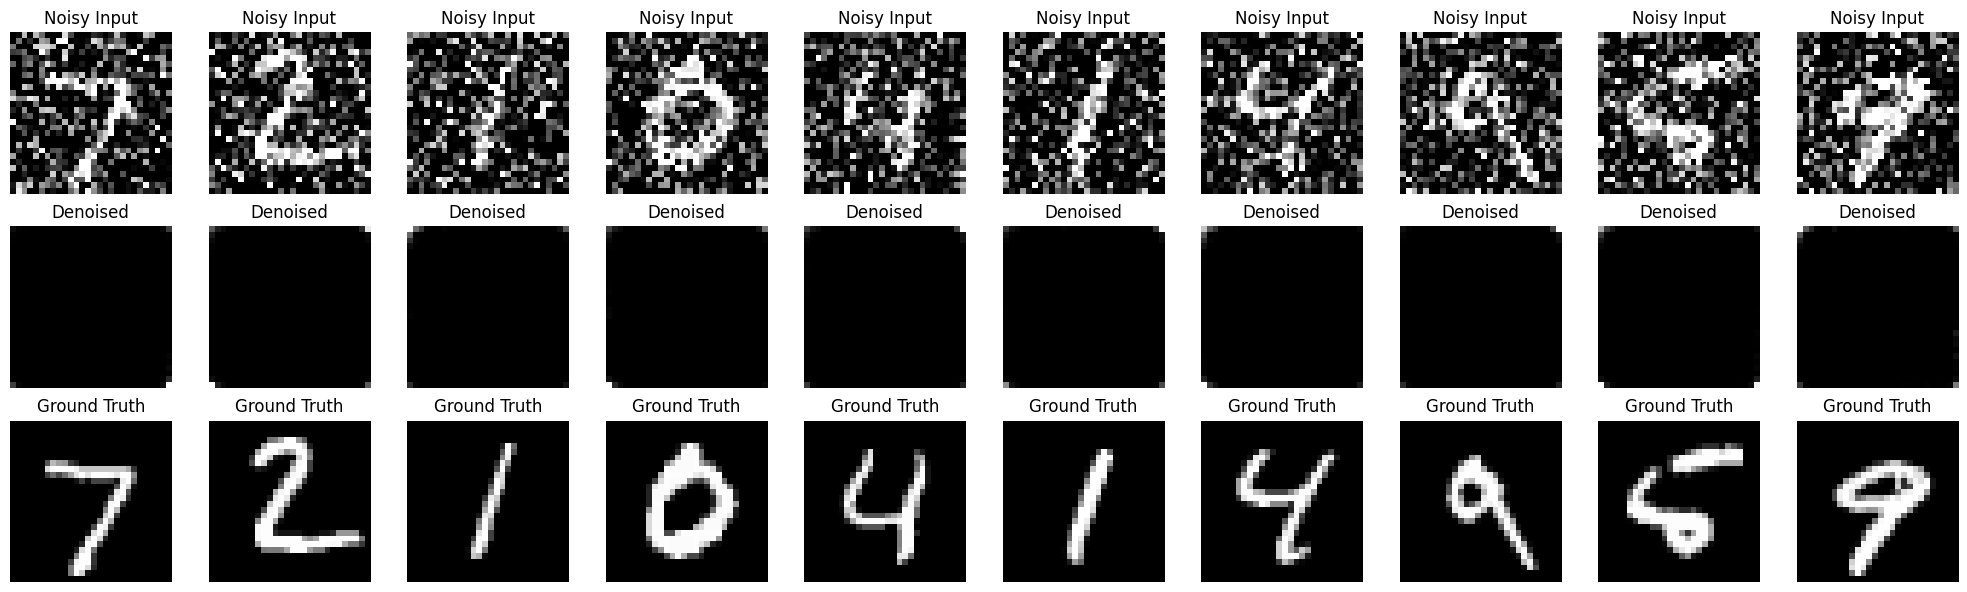

In [6]:
denoised_images = autoencoder.predict(x_test_noisy)

n = 10  # Number of samples to display
plt.figure(figsize=(20, 6))

for i in range(n):
    # Row 1: Noisy Input
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy Input")
    plt.axis("off")

    # Row 2: Denoised Output
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
    plt.title("Denoised")
    plt.axis("off")

    # Row 3: Ground Truth
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Ground Truth")
    plt.axis("off")

plt.tight_layout()
plt.show()